# Recommendation System Training (Association Rules)

This notebook trains a **recommendation model** using synthetic transaction data.

### Objectives
- Simulate user purchase behavior using mock data
- Train an association rule model using Apriori
- Generate product recommendations
- Export the trained model for use in Django backend

### Output
- `recommendation.pkl` (trained model)

## Personalization Strategy

The recommendation system incorporates personalization by leveraging user-specific interaction data.

Instead of training separate models per user, the system applies a global association rule model and adapts recommendations based on:

- User purchase history
- Current cart items
- Previous orders

This approach enables:
- Lightweight personalization without retraining
- Scalability across many users
- Real-time recommendation generation

However, the model does not explicitly learn individual user preferences, and recommendations are based on global patterns rather than user embeddings.

Future improvements could include collaborative filtering or hybrid recommendation techniques.

## Imports

In [40]:
import json
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori, association_rules
import random

##  Load Mock Transaction Data

We use synthetic transaction data where each row represents a customer order.

Example: ["Fresh Tomato", "Cavendish Banana"]

This replaces the need for a live database during model development.


In [49]:
items = [
    "Fresh Fuji Apple", "Cavendish Banana", "Fresh Tomato",
    "Valencia Orange", "Ripe Mango", "Fresh Strawberry",
    "Fresh Cucumber", "Fresh Bell Pepper", "Fresh Potato",
    "Fresh Guava", "Cherry Tomato", "Fresh Pomegranate",
    "Green Grapes", "Organic Carrot"
]

def generate_transactions(n=1000):
    transactions = []

    for _ in range(n):
        basket = set()

        # Pattern 1: Fruits combo
        if random.random() < 0.6:
            basket.update(["Cavendish Banana", "Fresh Fuji Apple"])

        # Pattern 2: Cooking combo
        if random.random() < 0.5:
            basket.update(["Fresh Tomato", "Organic Carrot"])

        # Pattern 3: Tropical combo
        if random.random() < 0.4:
            basket.update(["Valencia Orange", "Ripe Mango"])

        # Pattern 4: Salad combo (NEW)
        if random.random() < 0.4:
            basket.update(["Fresh Cucumber", "Fresh Bell Pepper"])

        # Pattern 5: Cooking add-on
        if random.random() < 0.3:
            basket.add("Fresh Potato")

        # 🍇 Add random noise (important)
        noise_items = random.sample(items, random.randint(1, 3))
        basket.update(noise_items)

        transactions.append(list(basket))

    return transactions

## Train-Test Split

To evaluate the model properly, the dataset is split into:
- Training data (80%)
- Testing data (20%)

The model is trained only on training data and evaluated on unseen test data.

In [50]:
transactions = generate_transactions(1000)
train_data, test_data = train_test_split(transactions, test_size=0.2, random_state=42)

## Data Preprocessing

The transaction data is transformed into a one-hot encoded format suitable for association rule mining.

In [51]:
def preprocess(transactions):
    all_items = sorted(set(item for t in transactions for item in t))

    encoded = []
    for t in transactions:
        row = {item: (item in t) for item in all_items}
        encoded.append(row)

    return pd.DataFrame(encoded)

df_train = preprocess(train_data)
df_train.head()

,Cavendish Banana,Cherry Tomato,Fresh Bell Pepper,Fresh Cucumber,Fresh Fuji Apple,Fresh Guava,Fresh Pomegranate,Fresh Potato,Fresh Strawberry,Fresh Tomato,Green Grapes,Organic Carrot,Ripe Mango,Valencia Orange
0,False,False,False,False,True,False,False,False,False,False,True,False,True,True
1,True,False,True,False,True,False,False,False,False,False,False,True,True,True
2,True,False,False,False,True,False,False,False,False,True,True,True,True,True
3,False,True,True,True,True,False,False,True,False,True,False,True,False,False
4,True,False,False,False,True,True,False,False,False,True,False,True,True,True


## Model Selection: Association Rule Mining

Apriori is used to extract frequent itemsets and generate association rules.

In [52]:
freq = apriori(df_train, min_support=0.01, use_colnames=True)

rules = association_rules(freq, metric="lift", min_threshold=1.0)

# Filter weak rules
rules = rules[(rules["confidence"] > 0.3) & (rules["lift"] > 1.2)]

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
6,frozenset({Cavendish Banana}),frozenset({Fresh Fuji Apple}),0.64375,0.62750,0.58250,0.904854,1.441999,0.178547,3.915051,0.860402
7,frozenset({Fresh Fuji Apple}),frozenset({Cavendish Banana}),0.62750,0.64375,0.58250,0.928287,1.441999,0.178547,4.967708,0.822868
26,frozenset({Fresh Cucumber}),frozenset({Fresh Bell Pepper}),0.47125,0.47875,0.39875,0.846154,1.767423,0.173139,3.388125,0.821191
27,frozenset({Fresh Bell Pepper}),frozenset({Fresh Cucumber}),0.47875,0.47125,0.39875,0.832898,1.767423,0.173139,3.164238,0.833006
70,frozenset({Fresh Tomato}),frozenset({Organic Carrot}),0.60125,0.60875,0.54375,0.904366,1.485611,0.177739,4.091114,0.819753


## Rule Evaluation Metrics

- Support → frequency of itemset  
- Confidence → reliability  
- Lift → strength of relationship  

Higher lift and confidence indicate stronger recommendations.

In [53]:
rules.sort_values(by="lift", ascending=False)[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10)

,antecedents,consequents,support,confidence,lift
61104,"frozenset({Fresh Bell Pepper, Cavendish Banana...","frozenset({Fresh Fuji Apple, Fresh Cucumber, O...",0.010,1.000000,9.523810
61101,"frozenset({Fresh Bell Pepper, Cavendish Banana...","frozenset({Fresh Tomato, Fresh Fuji Apple, Fre...",0.010,0.888889,8.888889
61063,"frozenset({Fresh Bell Pepper, Valencia Orange,...","frozenset({Fresh Fuji Apple, Fresh Cucumber, R...",0.010,0.888889,8.779150
60146,"frozenset({Valencia Orange, Fresh Cucumber, Fr...","frozenset({Cavendish Banana, Fresh Bell Pepper...",0.015,0.923077,8.687783
60143,"frozenset({Valencia Orange, Fresh Cucumber, Or...","frozenset({Fresh Tomato, Cavendish Banana, Fre...",0.015,0.857143,8.679928
60118,"frozenset({Fresh Bell Pepper, Fresh Tomato, Ch...","frozenset({Cavendish Banana, Fresh Cucumber, O...",0.015,0.923077,8.391608
60173,"frozenset({Fresh Cucumber, Fresh Tomato, Cherr...","frozenset({Cavendish Banana, Fresh Bell Pepper...",0.015,0.923077,8.391608
60172,"frozenset({Fresh Cucumber, Organic Carrot, Che...","frozenset({Fresh Tomato, Cavendish Banana, Fre...",0.015,0.857143,8.362369
61060,"frozenset({Fresh Bell Pepper, Valencia Orange,...","frozenset({Fresh Tomato, Fresh Fuji Apple, Fre...",0.010,0.800000,8.311688
60081,"frozenset({Fresh Bell Pepper, Valencia Orange,...","frozenset({Cavendish Banana, Fresh Cucumber, R...",0.015,0.857143,8.261618


## Explainable Recommendation System (XAI)

Recommendations are generated based on association rules.

Each recommendation includes:
- Reason (antecedent)
- Confidence
- Lift score

In [54]:
def recommend_with_explanation(rules, user_items, top_k=5):
    results = []

    for _, row in rules.iterrows():
        if set(row["antecedents"]).issubset(user_items):
            results.append({
                "recommendation": list(row["consequents"]),
                "because": list(row["antecedents"]),
                "confidence": row["confidence"],
                "lift": row["lift"]
            })

    # Sort by lift (ranking)
    results = sorted(results, key=lambda x: x["lift"], reverse=True)

    return results[:top_k]

## Test Recommendations

In [55]:
recommend_with_explanation(rules, {"Fresh Tomato"})

[{'recommendation': ['Fresh Fuji Apple', 'Fresh Cucumber', 'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.3097713097713098,
  'lift': 1.5784525338665467},
 {'recommendation': ['Cavendish Banana', 'Fresh Cucumber', 'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.3180873180873181,
  'lift': 1.5611647513488007},
 {'recommendation': ['Fresh Fuji Apple',
   'Fresh Bell Pepper',
   'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.30145530145530147,
  'lift': 1.5558983300918785},
 {'recommendation': ['Cavendish Banana',
   'Fresh Bell Pepper',
   'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.31185031185031187,
  'lift': 1.5495667669580713},
 {'recommendation': ['Fresh Cucumber', 'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.4386694386694387,
  'lift': 1.532469654740397}]

## Model Evaluation

Evaluation is performed using Hit Rate.

Method:
- Remove one item from a transaction
- Predict using remaining items
- Check if removed item appears in recommendations

In [57]:
def evaluate(rules, test_data, max_rules=200, max_tests=50):
    rules = rules.sample(min(max_rules, len(rules)))
    test_data = test_data[:max_tests]

    hits = 0
    total = 0

    for t in test_data:
        if len(t) < 2:
            continue

        for i in range(len(t)):
            input_items = set(t[:i] + t[i+1:])
            target = t[i]

            recs = recommend_with_explanation(rules, input_items)

            rec_items = []
            for r in recs:
                rec_items.extend(r["recommendation"])

            if target in rec_items:
                hits += 1
            total += 1

    return hits / total if total > 0 else 0

In [58]:
accuracy = evaluate(rules, test_data)
print("Hit Rate:", accuracy)

Hit Rate: 0.6395759717314488


## Lift Distribution Analysis

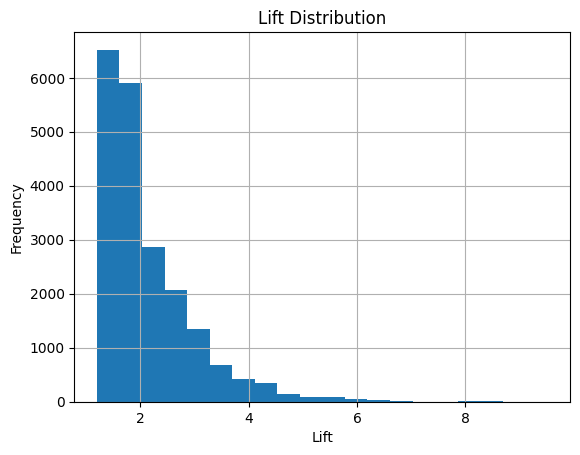

In [59]:
rules["lift"].hist(bins=20)
plt.title("Lift Distribution")
plt.xlabel("Lift")
plt.ylabel("Frequency")
plt.show()

## Support vs Confidence

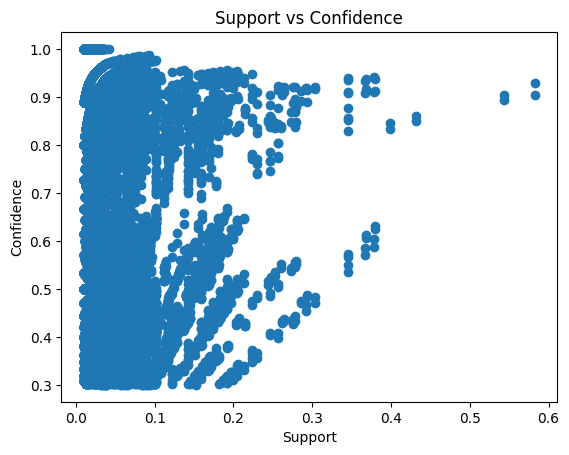

In [60]:
plt.scatter(rules["support"], rules["confidence"])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

## Model Deployment

The trained model is saved for integration into Django backend.

In [63]:
with open("rules.pkl", "wb") as f:
    pickle.dump(rules, f)

print("Model saved as rules.pkl")

Model saved as rules.pkl


## Load Model 

In [64]:
with open("rules.pkl", "rb") as f:
    loaded_rules = pickle.load(f)

recommend_with_explanation(loaded_rules, {"Fresh Tomato"})

[{'recommendation': ['Fresh Fuji Apple', 'Fresh Cucumber', 'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.3097713097713098,
  'lift': 1.5784525338665467},
 {'recommendation': ['Cavendish Banana', 'Fresh Cucumber', 'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.3180873180873181,
  'lift': 1.5611647513488007},
 {'recommendation': ['Fresh Fuji Apple',
   'Fresh Bell Pepper',
   'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.30145530145530147,
  'lift': 1.5558983300918785},
 {'recommendation': ['Cavendish Banana',
   'Fresh Bell Pepper',
   'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.31185031185031187,
  'lift': 1.5495667669580713},
 {'recommendation': ['Fresh Cucumber', 'Organic Carrot'],
  'because': ['Fresh Tomato'],
  'confidence': 0.4386694386694387,
  'lift': 1.532469654740397}]